# Week 8 — risk scores and calibration (Wednesday, 1 hour)

Six exercises on fc-10's `calibration` and `macro_preview` modules and Decision 6. The weights are **stated, not
fitted**, and every rate is **PLANTED TRUTH**. Read `README.md` in this folder first.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

sys.path.insert(0, str(Path.cwd().parents[1]))
from tools.tm_sim_source import load, fc10_module

tm_sim, metrics = load()
calibration = fc10_module("runtime.manufacturing.tuning.calibration")
challengers = fc10_module("runtime.manufacturing.tuning.challengers")
decision_log = fc10_module("runtime.manufacturing.tuning.decision_log")
macro_preview = fc10_module("runtime.manufacturing.tuning.macro_preview")

[d6] = [e for e in decision_log.load() if e["decision_id"] == "D6"]
a, ev = d6["assumptions"], d6["evidence"]
fit, hold = tm_sim.generate(), tm_sim.generate(seed=a["holdout_seed"])
spike, threshold, budget = ev["score"]["spike_spec"], ev["score"]["amount_reference"], a["budget_workload"]
print(d6["decision"], "·", d6["mitigants"][0][:90], "…")

HOLD · Watch the number of alerts tied at any score cap against the capacity that works them. A c …


## Exercise 1 — the score against the rules it blends, at one budget

                    in_sample  hold_out
queue                                  
ranked score 50/50        166       171
relative_spike            161       170
champion                  110       122 

overlap in-sample: {'both_rules': 91, 'champion_only': 19, 'rules_only': 14, 'score_caught': 166, 'score_only': 0, 'spike_only': 70}


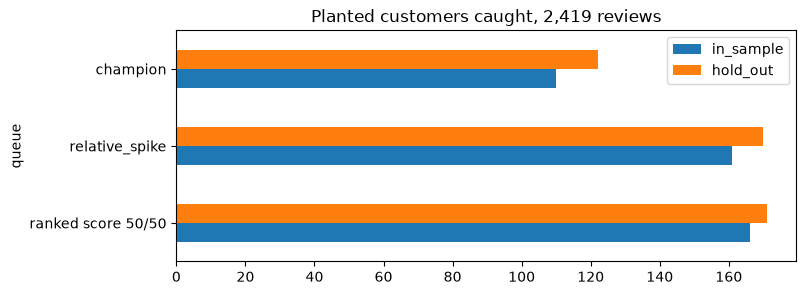

In [2]:
rows = [{"queue": "ranked score 50/50", **{s: ev["worked_to_budget"][s]["tp"] for s in ("in_sample", "hold_out")}}]
for name in ("relative_spike", "champion"):
    rows.append({"queue": name, **{s: ev["rules_as_they_run"][name][s]["tp"] for s in ("in_sample", "hold_out")}})
t = pd.DataFrame(rows).set_index("queue")
print(t, "\n\noverlap in-sample:", ev["overlap_in_sample"])
t.plot.barh(figsize=(8, 3), title=f"Planted customers caught, {budget:,} reviews");

**Read it.** The score beats the customer-baseline rule by a handful and finds nobody neither rule finds
(`score_only` is 0). It re-orders the same catches rather than adding coverage.

## Exercise 2 — ranking: does a higher band mean a likelier case?

    band   fitted  hold-out, same score
top 0.5% 0.456140              0.349333
  top 1% 0.055944              0.052055
  top 2% 0.019264              0.014519
  top 4% 0.004382              0.006628
  top 8% 0.001313              0.003176
 top 16% 0.002190              0.001772
 top 32% 0.000766              0.000660
top 100% 0.000464              0.000336 
inversions: {'hold_out': 0, 'in_sample': 1}


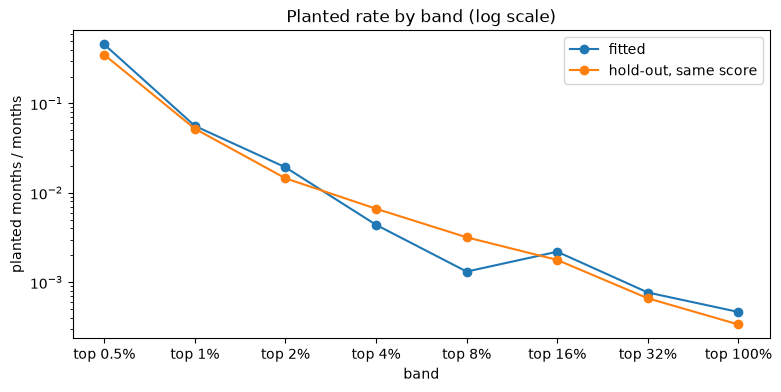

In [3]:
b = pd.DataFrame({"band": [f"top {100*x['top_fraction']:g}%" for x in ev["bands"]["in_sample"]],
                  "fitted": [x["rate"] for x in ev["bands"]["in_sample"]],
                  "hold-out, same score": [x["rate"] for x in ev["bands"]["hold_out_at_in_sample_edges"]]})
print(b.to_string(index=False), "\ninversions:", ev["bands"]["inversions"])
ax = b.set_index("band").plot(marker="o", logy=True, figsize=(9, 4), title="Planted rate by band (log scale)")
ax.set_ylabel("planted months / months");

**Read it.** Both lines fall band after band, so the **ranking** transfers. The top band is where they part:
46% where the score was built, 35% at the same edge on data it never saw.

## Exercise 3 — calibration, the scikit-learn way

`roc_auc_score` and `average_precision_score` measure **ranking** only. To turn a score into a probability, fit a
monotone map from score to outcome (isotonic regression) on one population and test it on the other.

In [4]:
def scored(pop):
    rows = calibration.months(pop, spike)
    s = np.array([calibration.score(r, a["weights"], threshold, spike["multiple"]) for r in rows])
    y = np.array([r["planted"] for r in rows], dtype=int)
    return s, y

(s_fit, y_fit), (s_hold, y_hold) = scored(fit), scored(hold)
for name, s, y in (("fitted", s_fit, y_fit), ("hold-out", s_hold, y_hold)):
    print(f"{name:9} AUC {roc_auc_score(y, s):.3f}   average precision {average_precision_score(y, s):.3f}")

iso = IsotonicRegression(out_of_bounds="clip").fit(s_fit, y_fit)
p_hold = iso.predict(s_hold)
print(f"\nBrier on hold-out: isotonic {brier_score_loss(y_hold, p_hold):.5f}   "
      f"'always the base rate' {brier_score_loss(y_hold, np.full_like(p_hold, y_fit.mean())):.5f}")
top = s_hold >= np.quantile(s_fit, 0.995)
print(f"top 0.5% edge on hold-out: predicted {p_hold[top].mean():.1%}, observed {y_hold[top].mean():.1%}")

fitted    AUC 0.927   average precision 0.547
hold-out  AUC 0.941   average precision 0.518

Brier on hold-out: isotonic 0.00246   'always the base rate' 0.00349
top 0.5% edge on hold-out: predicted 47.0%, observed 34.4%


**Read it.** AUC around 0.93 on both populations says the order is strong and holds out of sample. The isotonic map is honest on average, but at the very top
it carries the fitted population's rate onto a population where it is lower. That's the gap D6 records.

## Exercise 4 — the cap cliff, and what the tie-break costs

Sweep the cap. For each one, count the months tied at it, then work the budget twice: once with the live
queue's **alphabetical** tie-break, and once with a tie-break that cheats by reading the labels. What the cap
costs is the drop from the uncapped 166.

 cap  tied  caught  if the tie-break could see
 300   152     166                         166
 200   330     166                         166
 150   615     166                         166
 100  1652     166                         166
  90  2109     166                         166
  80  2868     143                         165
  75  3375     112                         165
  70  3961     104                         166
  60  5694      75                         170
  50  8480      49                         176


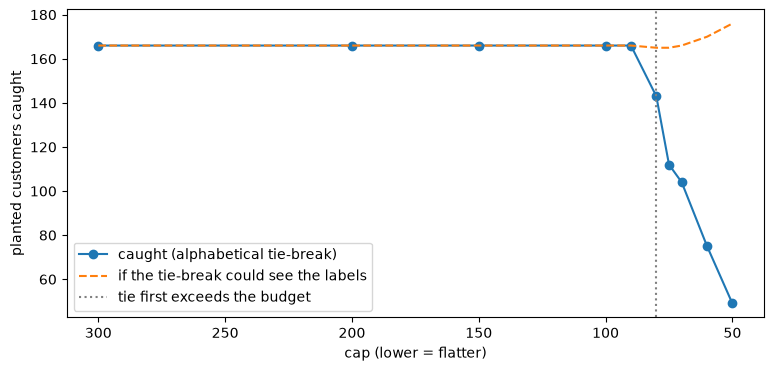

In [5]:
rows_fit = calibration.months(fit, spike)
planted = {c.customer_id for c in fit.customers if c.planted}
out = []
for cap in (300, 200, 150, 100, 90, 80, 75, 70, 60, 50):
    q = calibration.ranked(rows_fit, a["weights"], threshold, spike["multiple"], cap)
    blind = len({r["customer_id"] for _s, r in q[:budget]} & planted)
    cheat_q = sorted(q, key=lambda sr: (-sr[0], not sr[1]["planted"], sr[1]["customer_id"], sr[1]["month"]))
    cheat = len({r["customer_id"] for _s, r in cheat_q[:budget]} & planted)
    out.append({"cap": cap, "tied": sum(1 for s, _r in q if s >= cap), "caught": blind, "if the tie-break could see": cheat})
c = pd.DataFrame(out)
print(c.to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(c["cap"], c["caught"], marker="o", label="caught (alphabetical tie-break)")
ax.plot(c["cap"], c["if the tie-break could see"], ls="--", label="if the tie-break could see the labels")
ax.axvline(c[c["tied"] > budget]["cap"].max(), color="grey", ls=":", label="tie first exceeds the budget")
ax.invert_xaxis(); ax.set(xlabel="cap (lower = flatter)", ylabel="planted customers caught"); ax.legend();

**Read it.** Flat until the tie outgrows the budget, then a cliff. The dashed line is not a policy anyone
could run, because it reads the answers (at low caps it even beats the uncapped score). It shows the missed
cases were inside the tie all along, and the alphabetical order simply didn't reach them.

## Exercise 5 — do the weights matter?

               fitted  hold-out
amount weight                  
0                 162       170
20                168       174
40                166       172
50                166       171
60                161       171
80                152       159
100               110       117


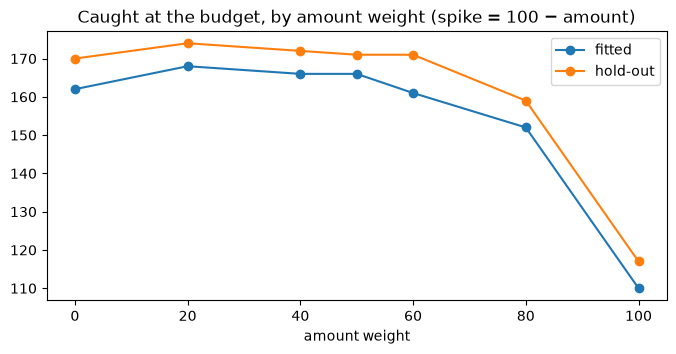

In [6]:
w = pd.DataFrame([{"amount weight": x["amount"], "fitted": x["in_sample"]["tp"], "hold-out": x["hold_out"]["tp"]}
                  for x in ev["weight_sweep"]]).set_index("amount weight")
print(w)
w.plot(marker="o", figsize=(8, 3.5), title="Caught at the budget, by amount weight (spike = 100 − amount)");

**Read it.** 0 is the customer-baseline rule alone, 100 is the champion. Anywhere from 20 to 60 lands within a
few customers, so the split is not the decision.

## Exercise 6 — the estate: what a macro change DOES

The estate's macro score has no outcome labels to fit to. The preview runs fc-10's **real** scorer against a
candidate config and reports what moves. It does not say whether the change is right.

In [7]:
for label, change in (("lift the cap to 400", {"max_score": 400}), ("high_value 15 → 5", {"high_value": 5})):
    cand = macro_preview.governed()
    for k, v in change.items():
        (cand if k == "max_score" else cand["signal_points"])[k] = v
    p = macro_preview.preview(cand)
    print(f"{label}: at cap {p['before']['at_cap']} → {p['after']['at_cap']}, "
          f"{len(p['band_moves'])} band moves, queue {p['queue']}")

lift the cap to 400: at cap 6 → 0, 0 band moves, queue {'entered_top': [], 'left_top': [], 'moved_within_top': ['E-ZETA', 'E-GAMMA', 'E-WESTBRIDGE', 'E-CRANS', 'E-CONTINENTAL']}


high_value 15 → 5: at cap 6 → 5, 7 band moves, queue {'entered_top': ['E-VANTAGE'], 'left_top': ['E-CONTINENTAL'], 'moved_within_top': ['E-CRANS', 'E-IRONBRIDGE', 'E-OAKMERE']}


## For the weekend note

Fill in `weekend_note.md`: the three queues at the budget, what transferred to the hold-out and what didn't,
where the cap became binding, and what you would show a model-risk reviewer before changing a macro weight.